13 Clase final 

In [61]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, silhouette_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

#Libreiras de pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
# Selección de variables
from sklearn.feature_selection import SelectKBest, f_classif
#Validaciones cruzadas
from sklearn.model_selection import cross_val_score, GridSearchCV
import os

print ("librerias ok")

librerias ok


In [ ]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\DataTitanic


In [ ]:
#Abrir el df
df = pd.read_csv("./data/heart_disease_uci.csv")

In [ ]:
# Primero comenzar a explorar el dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [12]:
#Cuantas filas y columnas tengo
df.shape
print(f"Cantidad filas: {df.shape[0]}")
print(f"Cantidad columnas: {df.shape[1]}")

Cantidad filas: 920
Cantidad columnas: 16


In [ ]:
#Analisis descriptivos
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


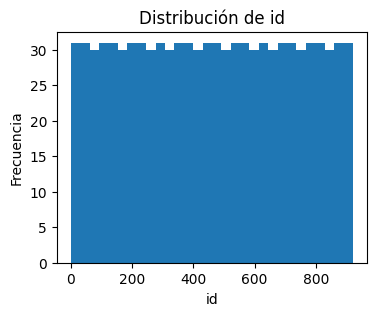

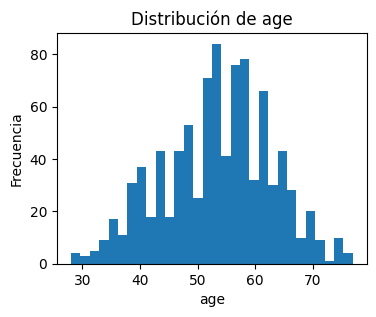

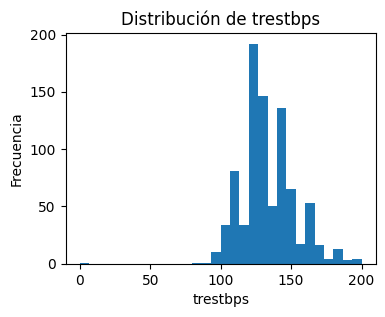

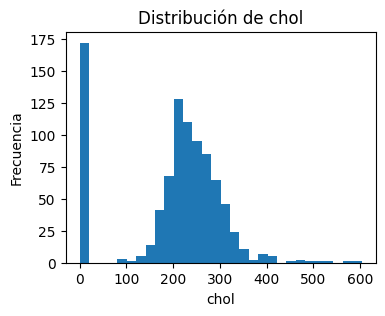

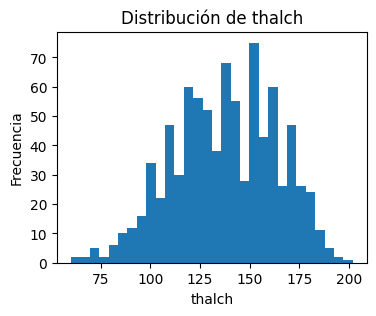

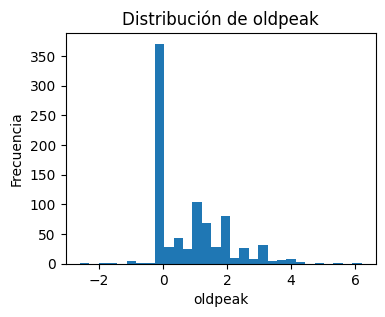

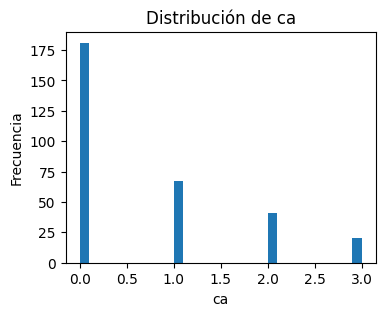

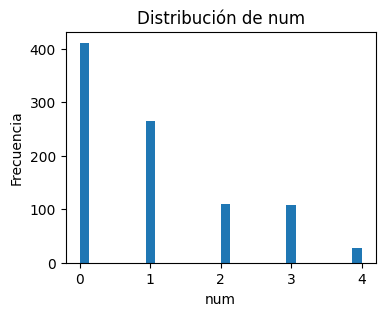

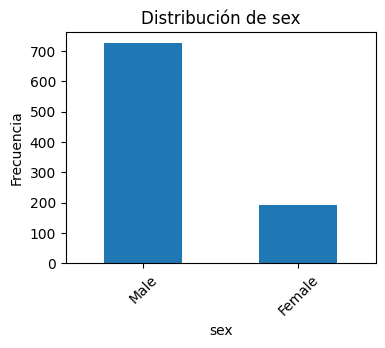

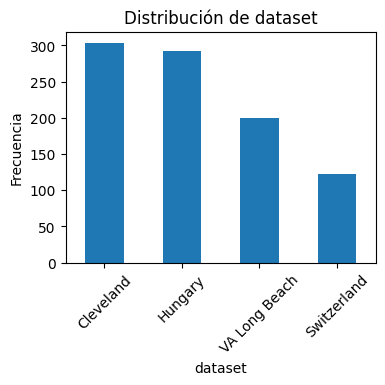

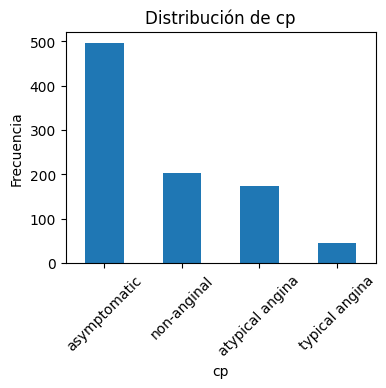

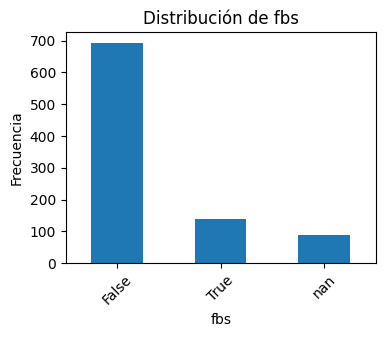

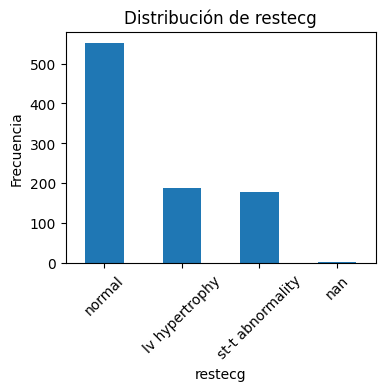

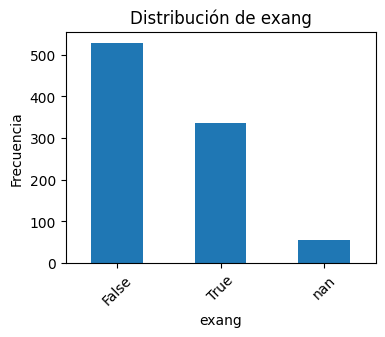

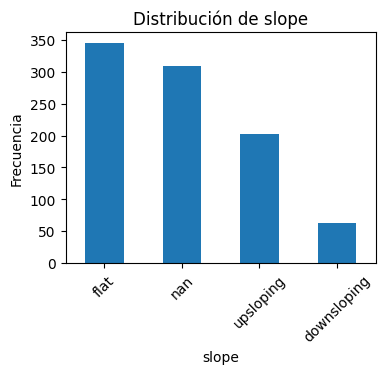

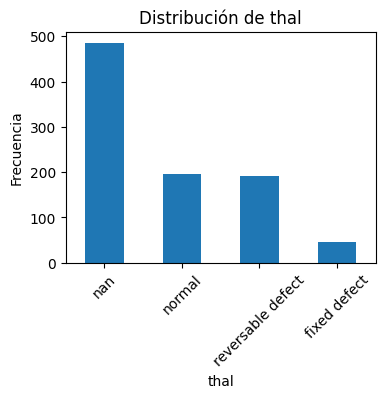

In [ ]:
#Plot de distribucion

# Variables numéricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(4,3))
    df[col].hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(False)
    plt.show()

#Variables categoricas
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    plt.figure(figsize=(4,3))
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.show()


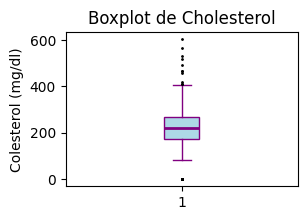

In [32]:
#Boxplots

plt.figure(figsize=(3,2))

plt.boxplot(
    df["chol"].dropna(),
    patch_artist=True,  # Permite colorear la caja
    boxprops=dict(facecolor="lightblue", color="purple"),
    medianprops=dict(color="purple", linewidth=2),
    whiskerprops=dict(color="purple"),
    capprops=dict(color="purple"),
    flierprops=dict(
        marker='o',
        markersize=1,
        markerfacecolor='black',
        markeredgecolor='black'
    )
)
plt.title("Boxplot de Cholesterol")
plt.ylabel("Colesterol (mg/dl)")
plt.show()

In [ ]:
#Cuales son los tipos de clasificaciones en cada set de datos categóricos
print("CP", df['cp'].unique())
print("SEX",df['sex'].unique())
print("DATASET", df['dataset'].unique())
print("RESTECG", df['restecg'].unique())
print("EXANG", df['exang'].unique())
print("FBS", df['fbs'].unique())
print("SLOPE", df['slope'].unique())
print("THAL", df['thal'].unique())


CP <StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str
SEX <StringArray>
['Male', 'Female']
Length: 2, dtype: str
DATASER <StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str
RESTECG <StringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
EXANG [False True nan]
FBS [True False nan]
SLOPE <StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
THAL <StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str


##### Explicación de algunas de las variables:
##### Variables númericas
- `Age (Edad)`: edad del paciente
- `trestbps (Presión arterial)`: presion arterial en reposo medida en mm Hg. 
- `Chol (Colesterol)`: Nievel de colesterol sérico en mg/dl.
- `Thalch (Frecuencia cardíaca)`: Frecuencia cárdiaca maxima alcanzada. 

##### Variables categóricas
- `Sex`: Female y Male 
- `cp (Tipo de dolor)`: Describe el tipo de dolor en el pecho con categorías como "Typical Angina" o  asymptomatic 
- `thal (Prueba de talio)`: resune los resultados de una prueba de esfuerzo con talio 
- `restecg (Electrocardiograma)`: multiples categorias de diagnosticos 


##### Variables booleanas
- `fbs (Azúcar en sangre)`: Indica si el azúcar en sangre en ayunas es mayor a 120 mg/dl (T/F)
- `Exang (angina)`: Presencia de angina inducida por ejercicio 

##### Variables objetivo
- `num (variable objetivo)`: Grado de enfermedad cardíaca (0-4), que combvertiremos en binaria para clasificación


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_16768\2033552208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x ="num", palette="pastel")


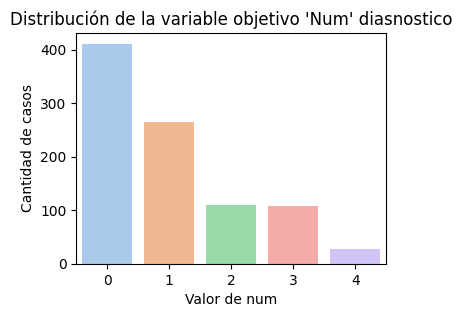

In [ ]:
#Profundizamos el analisis en la variable objetivo

plt.figure(figsize=(4,3))
sns.countplot(data = df, x ="num", palette="pastel")
plt.title ("Distribución de la variable objetivo 'Num' diasnostico")
plt.xlabel ("Valor de num")
plt.ylabel ("Cantidad de casos")
plt.show()



Esto muestra que la mayoria de los casos los pacientes no tiene ningun riesgo de enfermedad (0)

Pero si agrupamos 1-4 se iguala a los que no tienen ningun riesgo de enfermedad, mas alla de la magnitud tenemos:
- 0 sin riesgo 
- 1-4, si tiene riesgo enfermedadees pero de distintas magnitudes

Entonces la primera pregunta podría ser solamente si tiene o no riesgo de enfermedad. Sin importar el grado o magnitud de la enfermedad.



C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_16768\2802162069.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x ="enfermedad", palette="pastel")


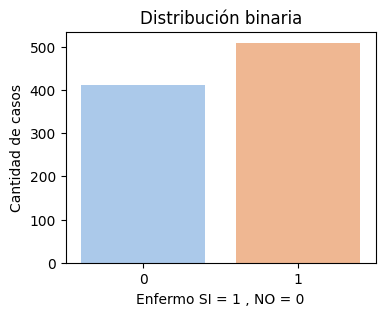

In [ ]:
#se crea nueva columna binaria "enfermo"
df["enfermedad"] = df["num"].apply(lambda x:1 if x > 0 else 0)

# VIualizamos
plt.figure(figsize=(4,3))
sns.countplot(data = df, x ="enfermedad", palette="pastel")
plt.title ("Distribución binaria")
plt.xlabel ("Enfermo SI = 1 , NO = 0" )
plt.ylabel ("Cantidad de casos")
plt.show()

#Aca se ve claramente que hay mas personas enfermas que sanas

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_16768\2323498453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=valores_nulos.index, x=valores_nulos.values, palette="pastel")


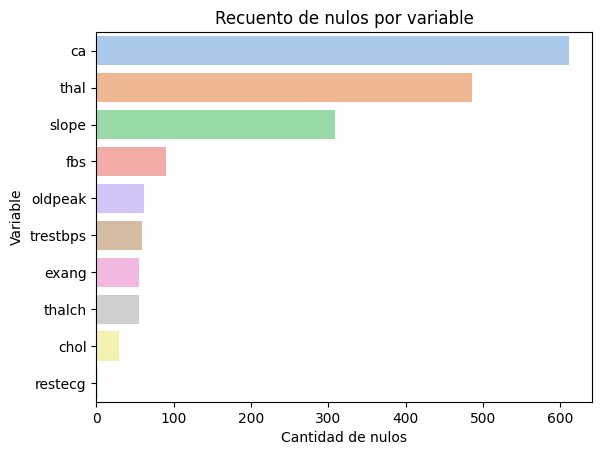

id             0.0
age            0.0
sex            0.0
dataset        0.0
cp             0.0
trestbps       6.4
chol           3.3
fbs            9.8
restecg        0.2
thalch         6.0
exang          6.0
oldpeak        6.7
slope         33.6
ca            66.4
thal          52.8
num            0.0
enfermedad     0.0
dtype: float64


In [50]:
# Analisis de valores nulls por cada variable

valores_nulos = df.isnull().sum()

#Me quedo solo con las columnas que tienen valores nulos
valores_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)
print(valores_nulos)

#Los visualizamos
plt.Figure(figsize=(5, 4))
# plt.barh(valores_nulos.index, valores_nulos.values)
sns.barplot(y=valores_nulos.index, x=valores_nulos.values, palette="pastel")
plt.title( "Recuento de nulos por variable")
plt.xlabel("Cantidad de nulos")
plt.ylabel("Variable")
plt.show()


#Si lo hacemos en porcentajes del total
porcentaje_nulos = round((df.isnull().sum() / len(df)) * 100, 1)
print(porcentaje_nulos)

Las variables slope; ca; thal son las que mas % de valores faltantes tienen

Tenemos que preguntarnos si son relevantes o no

Por ahora vamos a imputar valores para considerarlas

- Para variable numerica: media o mediana
- Para variable categorica: moda, pero despues las voy a tener que codificar

Lo primero que vamos a hacer es dividir las variables segun su tipo


In [58]:
#Solo me quedo con los nombres de esas variables y las pongo en una lista
variables_numericas = df.select_dtypes(["int64", "float64"]).columns.drop(["id", "num"]).to_list()
print(variables_numericas)

variables_categoricas = df.select_dtypes(["object"]).columns.to_list()
print(variables_categoricas)



['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'enfermedad']
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_16768\2541736481.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(["object"]).columns.to_list()


In [62]:
# Imputacion
# Imputacion

variables_numericas = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak'] # se exluyen , 'ca', 'enfermedad'
variables_categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'] #  se exluye'dataset', 

#Pipeline para variables numericas: imputacion por media + escalado
pipeline_numerico = Pipeline ( steps = [
    ("imputacion", SimpleImputer (strategy = "mean")),
    ("escalado", StandardScaler())
])


#Pipeline para variables categoricas: imputacion por moda + codificacion one-hot
pipeline_categorico = Pipeline ( steps = [
    ("imputacion", SimpleImputer (strategy = "most_frequent")),
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])


#Pipeline general de preprocesamiento
preprocesador = ColumnTransformer (transformers= [
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas)
])